[*********************100%***********************]  2 of 2 completed


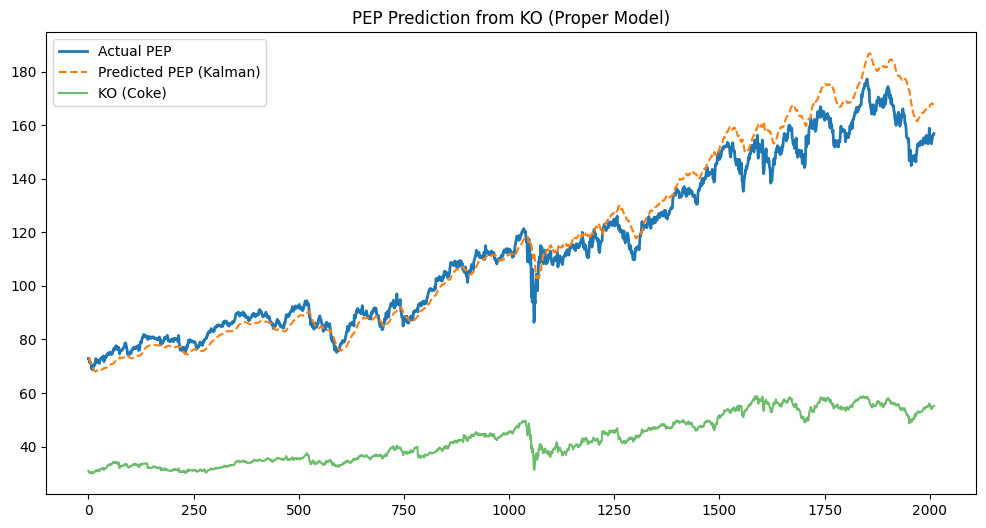

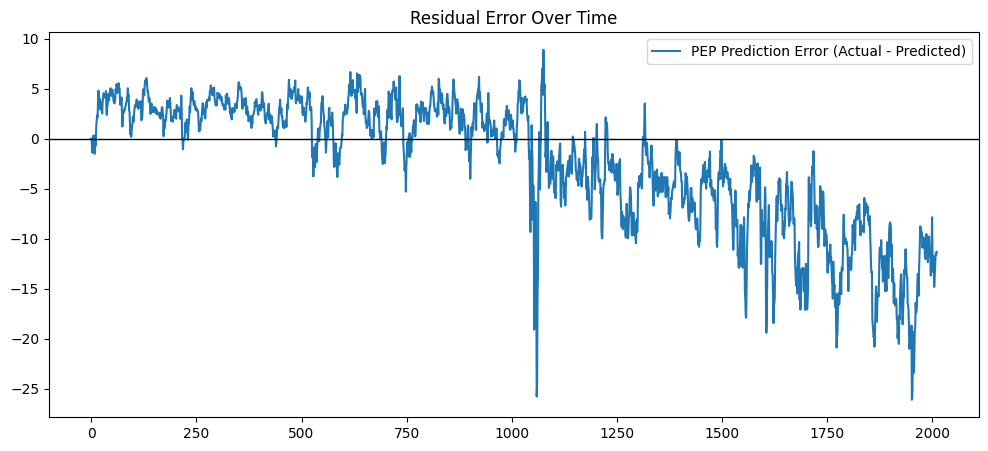

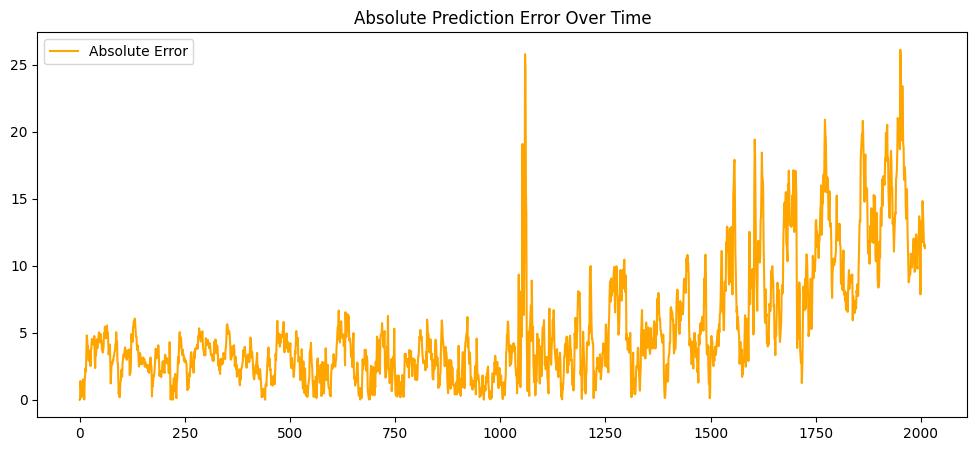

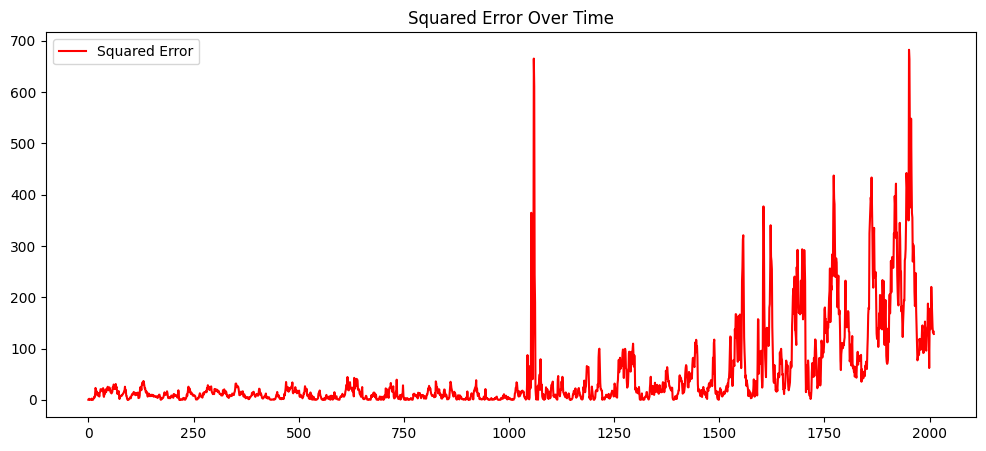

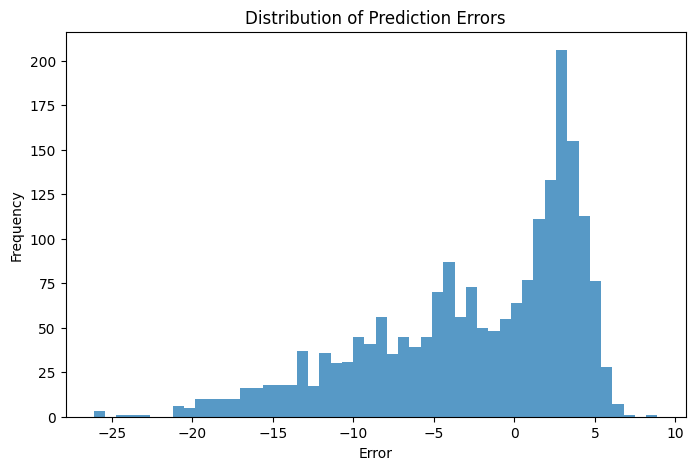

In [42]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# ----------------------------
# LOAD DATA
# ----------------------------
tickers = ["KO", "PEP"]
data = yf.download(tickers, start="2016-01-01", end="2024-01-01")["Close"]
data = data.dropna()

# ----------------------------
# RETURNS
# ----------------------------
returns = data.pct_change().dropna()

y = returns["PEP"].values
x = returns["KO"].values

n = len(y)

# ----------------------------
# KALMAN FILTER (REAL MODEL)
# ----------------------------
def kalman_filter(x, y):
    x_hat = np.zeros((2, n))
    P = np.eye(2)

    A = np.eye(2)
    Q = 1e-5 * np.eye(2)
    R = 1e-3

    y_preds = np.zeros(n)

    for t in range(1, n):

        H = np.array([[1, x[t-1]]])  # ONLY past info

        x_pred = A @ x_hat[:, t-1]
        P_pred = A @ P @ A.T + Q

        y_pred = (H @ x_pred).item()
        y_preds[t] = y_pred

        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)

        error = y[t] - y_pred
        x_hat[:, t] = x_pred + K.flatten() * error
        P = (np.eye(2) - K @ H) @ P_pred

    return y_preds

# ----------------------------
# RUN MODEL
# ----------------------------
pred_returns = kalman_filter(x, y)

# ----------------------------
# REBUILD PRICE FROM RETURNS
# ----------------------------
pep_prices = data["PEP"].iloc[1:].values  # align with returns
pred_prices = np.zeros_like(pep_prices)

pred_prices[0] = pep_prices[0]

for t in range(1, len(pred_prices)):
    pred_prices[t] = pred_prices[t-1] * (1 + pred_returns[t])

# ----------------------------
# ALIGN KO FOR PLOT
# ----------------------------
ko_prices = data["KO"].iloc[1:].values

# ----------------------------
# FINAL PLOT (WHAT YOU ASKED)
# ----------------------------
plt.figure(figsize=(12,6))

plt.plot(pep_prices, label="Actual PEP", linewidth=2)
plt.plot(pred_prices, label="Predicted PEP (Kalman)", linestyle="--")
plt.plot(ko_prices, label="KO (Coke)", alpha=0.7)

plt.title("PEP Prediction from KO (Proper Model)")
plt.legend()
plt.show()

# ----------------------------
# ERROR COMPUTATION
# ----------------------------
error = pep_prices - pred_prices
abs_error = np.abs(error)
squared_error = error**2

# ----------------------------
# 1. RAW ERROR (Residual Plot)
# ----------------------------
plt.figure(figsize=(12,5))
plt.plot(error, label="PEP Prediction Error (Actual - Predicted)")
plt.axhline(0, color='black', linewidth=1)
plt.title("Residual Error Over Time")
plt.legend()
plt.show()

# ----------------------------
# 2. ABSOLUTE ERROR
# ----------------------------
plt.figure(figsize=(12,5))
plt.plot(abs_error, label="Absolute Error", color="orange")
plt.title("Absolute Prediction Error Over Time")
plt.legend()
plt.show()

# ----------------------------
# 3. SQUARED ERROR (Penalty View)
# ----------------------------
plt.figure(figsize=(12,5))
plt.plot(squared_error, label="Squared Error", color="red")
plt.title("Squared Error Over Time")
plt.legend()
plt.show()

# ----------------------------
# 4. ERROR DISTRIBUTION (Histogram)
# ----------------------------
plt.figure(figsize=(8,5))
plt.hist(error, bins=50, alpha=0.75)
plt.title("Distribution of Prediction Errors")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

[*********************100%***********************]  2 of 2 completed


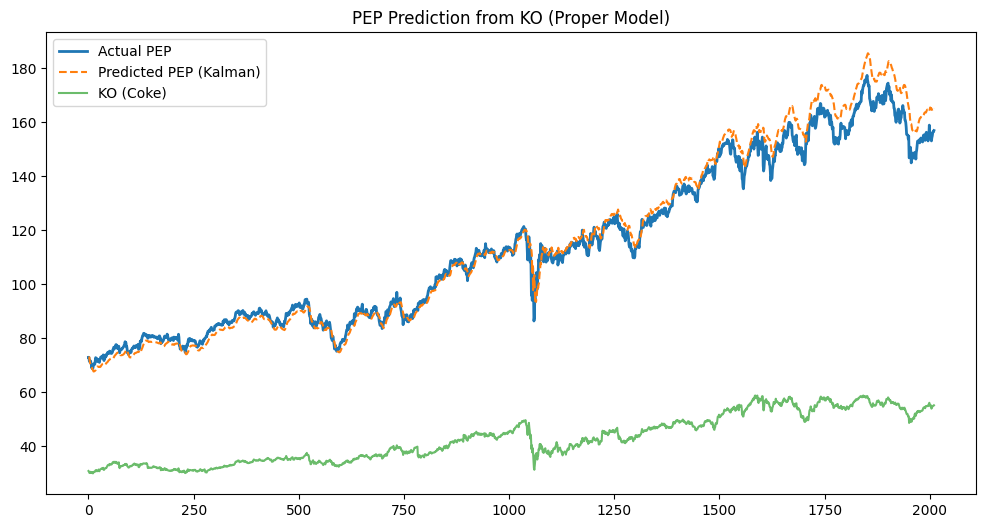

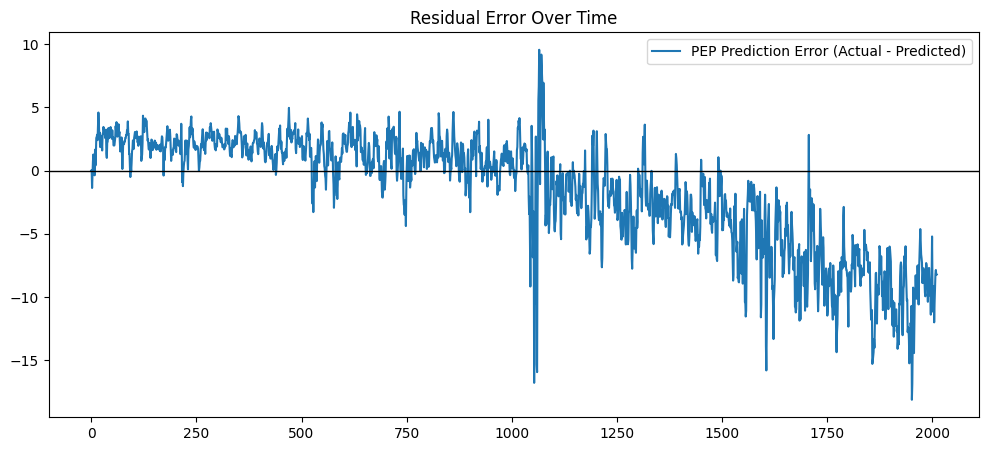

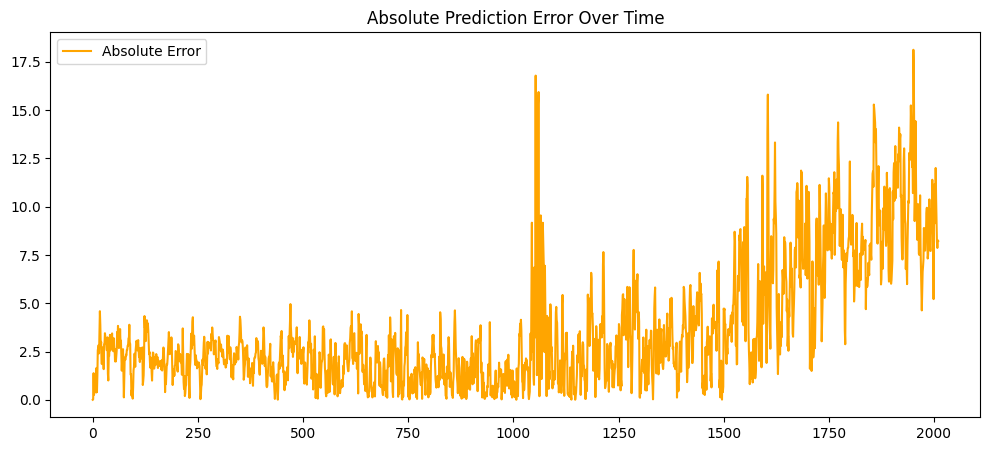

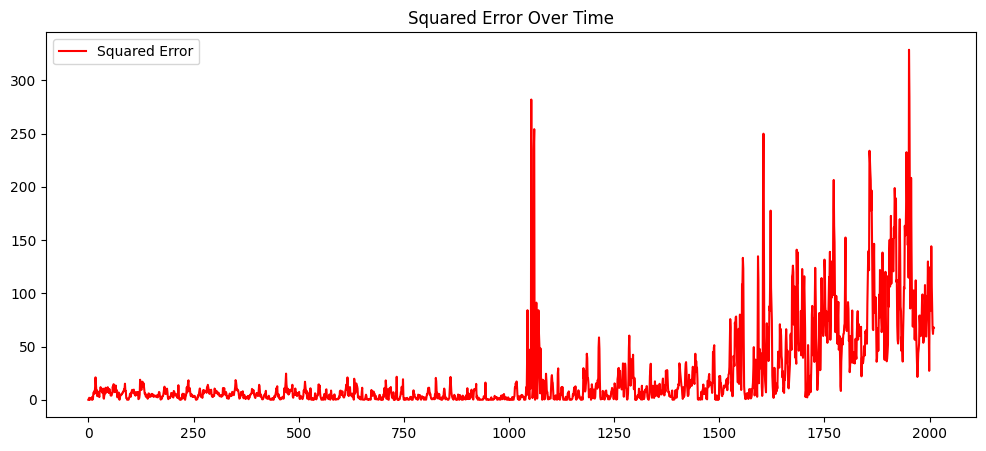

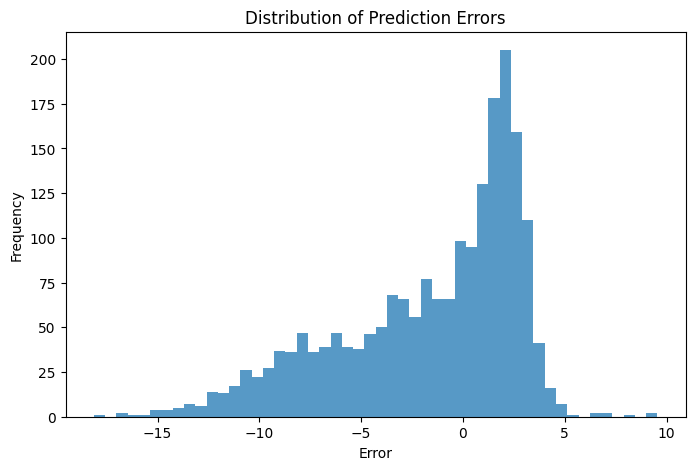

In [28]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# ----------------------------
# LOAD DATA
# ----------------------------
tickers = ["KO", "PEP"]
data = yf.download(tickers, start="2016-01-01", end="2024-01-01")["Close"]
data = data.dropna()

# ----------------------------
# RETURNS
# ----------------------------
returns = data.pct_change().dropna()

y = returns["PEP"].values
x = returns["KO"].values

n = len(y)

# ----------------------------
# KALMAN FILTER (REAL MODEL)
# ----------------------------
def kalman_filter(x, y):
    x_hat = np.zeros((3, n))  # [alpha, beta1, beta2]
    P = np.eye(3)

    A = np.eye(3)
    Q = 1e-3 * np.eye(3)   # MORE adaptive
    R = 1e-2

    y_preds = np.zeros(n)

    for t in range(2, n):

        # Features: KO lag + PEP momentum
        H = np.array([[1, x[t-1], y[t-1]]])

        x_pred = A @ x_hat[:, t-1]
        P_pred = A @ P @ A.T + Q

        y_pred = (H @ x_pred).item()
        y_preds[t] = y_pred

        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)

        error = y[t] - y_pred
        x_hat[:, t] = x_pred + K.flatten() * error
        P = (np.eye(3) - K @ H) @ P_pred

    return y_preds

# ----------------------------
# RUN MODEL
# ----------------------------
pred_returns = kalman_filter(x, y)

# ----------------------------
# REBUILD PRICE FROM RETURNS
# ----------------------------
pep_prices = data["PEP"].iloc[1:].values  # align with returns
pred_prices = np.zeros_like(pep_prices)

pred_prices[0] = pep_prices[0]

for t in range(1, len(pred_prices)):
    pred_prices[t] = pred_prices[t-1] * (1 + pred_returns[t])

# ----------------------------
# ALIGN KO FOR PLOT
# ----------------------------
ko_prices = data["KO"].iloc[1:].values

# ----------------------------
# FINAL PLOT (WHAT YOU ASKED)
# ----------------------------
plt.figure(figsize=(12,6))

plt.plot(pep_prices, label="Actual PEP", linewidth=2)
plt.plot(pred_prices, label="Predicted PEP (Kalman)", linestyle="--")
plt.plot(ko_prices, label="KO (Coke)", alpha=0.7)

plt.title("PEP Prediction from KO (Proper Model)")
plt.legend()
plt.show()

# ----------------------------
# ERROR COMPUTATION
# ----------------------------
error = pep_prices - pred_prices
abs_error = np.abs(error)
squared_error = error**2

# ----------------------------
# 1. RAW ERROR (Residual Plot)
# ----------------------------
plt.figure(figsize=(12,5))
plt.plot(error, label="PEP Prediction Error (Actual - Predicted)")
plt.axhline(0, color='black', linewidth=1)
plt.title("Residual Error Over Time")
plt.legend()
plt.show()

# ----------------------------
# 2. ABSOLUTE ERROR
# ----------------------------
plt.figure(figsize=(12,5))
plt.plot(abs_error, label="Absolute Error", color="orange")
plt.title("Absolute Prediction Error Over Time")
plt.legend()
plt.show()

# ----------------------------
# 3. SQUARED ERROR (Penalty View)
# ----------------------------
plt.figure(figsize=(12,5))
plt.plot(squared_error, label="Squared Error", color="red")
plt.title("Squared Error Over Time")
plt.legend()
plt.show()

# ----------------------------
# 4. ERROR DISTRIBUTION (Histogram)
# ----------------------------
plt.figure(figsize=(8,5))
plt.hist(error, bins=50, alpha=0.75)
plt.title("Distribution of Prediction Errors")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

[*********************100%***********************]  2 of 2 completed


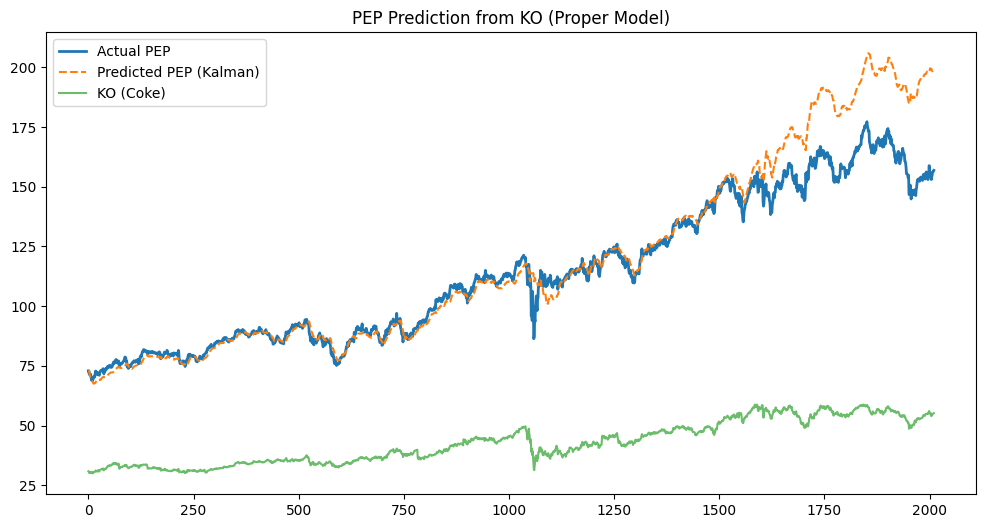

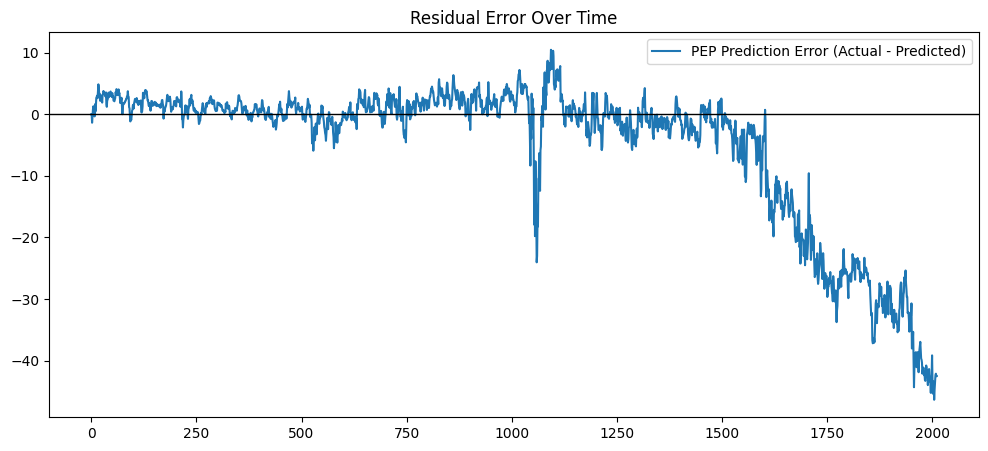

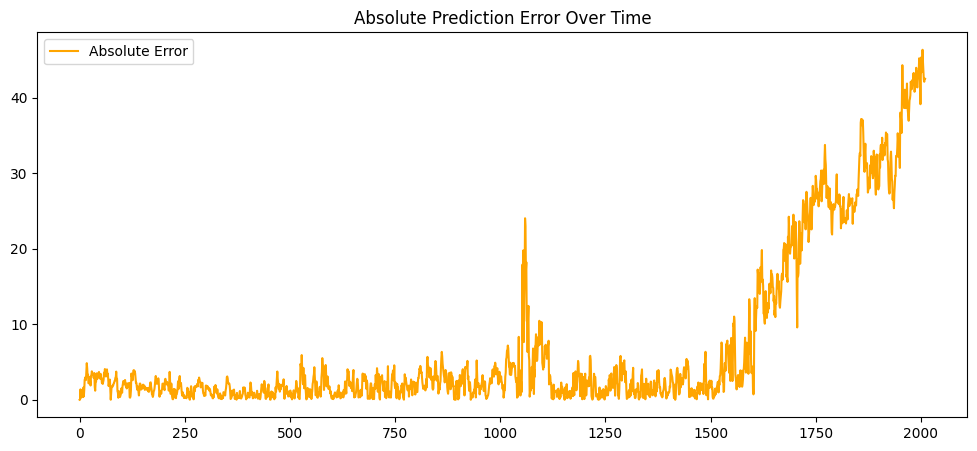

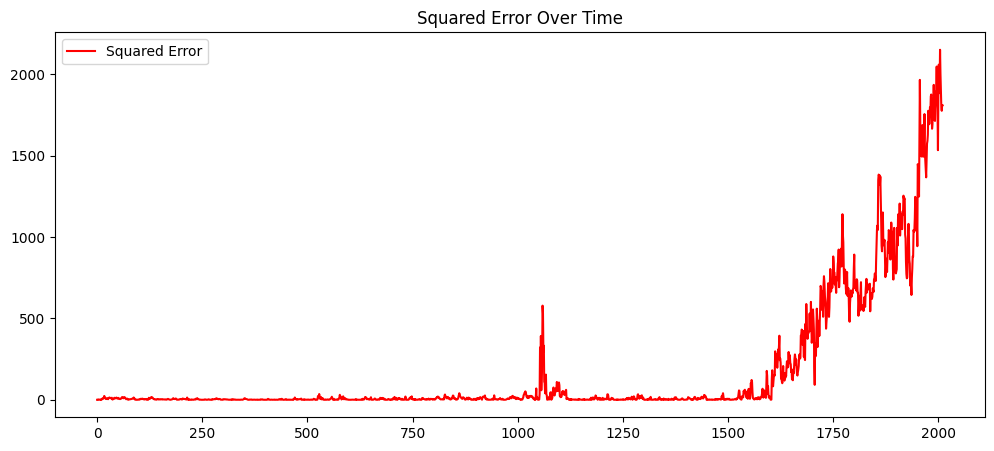

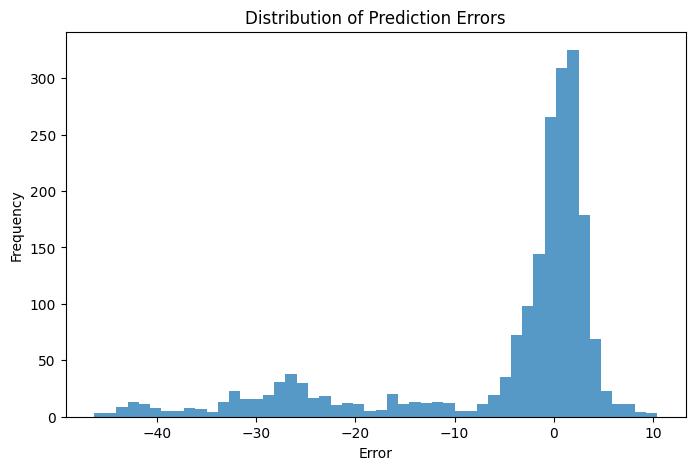

In [31]:




import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# ----------------------------
# LOAD DATA
# ----------------------------
tickers = ["KO", "PEP"]
data = yf.download(tickers, start="2016-01-01", end="2024-01-01")["Close"]
data = data.dropna()

# ----------------------------
# RETURNS
# ----------------------------
returns = data.pct_change().dropna()

y = returns["PEP"].values
x = returns["KO"].values

n = len(y)

# ----------------------------
# KALMAN FILTER (REAL MODEL)
# ----------------------------
def kalman_filter(x, y):
    x_hat = np.zeros((3, n))  # [alpha, beta1, beta2]
    P = np.eye(3)

    A = np.eye(3)

    R = 1e-2
    lambda_ = 0.98  # forgetting factor

    y_preds = np.zeros(n)

    for t in range(2, n):

        # ----------------------------
        # FEATURES (KO + momentum)
        # ----------------------------
        H = np.array([[1, x[t-1], y[t-1]]])

        # ----------------------------
        # ADAPTIVE NOISE (key fix for dips)
        # ----------------------------
        vol = np.var(y[max(0, t-20):t])
        Q = (1e-4 + 5 * vol) * np.eye(3)

        # ----------------------------
        # PREDICT
        # ----------------------------
        x_pred = A @ x_hat[:, t-1]
        P_pred = (A @ P @ A.T + Q) / lambda_

        y_pred = (H @ x_pred).item()
        y_preds[t] = y_pred

        # ----------------------------
        # SHOCK DETECTION (RESET LOGIC)
        # ----------------------------
        error = y[t] - y_pred

        if abs(error) > 3 * np.std(y):
            x_hat[:, t] = 0
            P = np.eye(3) * 10
            continue

        # ----------------------------
        # UPDATE
        # ----------------------------
        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)

        x_hat[:, t] = x_pred + K.flatten() * error
        P = (np.eye(3) - K @ H) @ P_pred

    return y_preds

# ----------------------------
# RUN MODEL
# ----------------------------
pred_returns = kalman_filter(x, y)

# ----------------------------
# REBUILD PRICE FROM RETURNS
# ----------------------------
pep_prices = data["PEP"].iloc[1:].values  # align with returns
pred_prices = np.zeros_like(pep_prices)

pred_prices[0] = pep_prices[0]

for t in range(1, len(pred_prices)):
    pred_prices[t] = pred_prices[t-1] * (1 + pred_returns[t])

# ----------------------------
# ALIGN KO FOR PLOT
# ----------------------------
ko_prices = data["KO"].iloc[1:].values

# ----------------------------
# FINAL PLOT (WHAT YOU ASKED)
# ----------------------------
plt.figure(figsize=(12,6))

plt.plot(pep_prices, label="Actual PEP", linewidth=2)
plt.plot(pred_prices, label="Predicted PEP (Kalman)", linestyle="--")
plt.plot(ko_prices, label="KO (Coke)", alpha=0.7)

plt.title("PEP Prediction from KO (Proper Model)")
plt.legend()
plt.show()

# ----------------------------
# ERROR COMPUTATION
# ----------------------------
error = pep_prices - pred_prices
abs_error = np.abs(error)
squared_error = error**2

# ----------------------------
# 1. RAW ERROR (Residual Plot)
# ----------------------------
plt.figure(figsize=(12,5))
plt.plot(error, label="PEP Prediction Error (Actual - Predicted)")
plt.axhline(0, color='black', linewidth=1)
plt.title("Residual Error Over Time")
plt.legend()
plt.show()

# ----------------------------
# 2. ABSOLUTE ERROR
# ----------------------------
plt.figure(figsize=(12,5))
plt.plot(abs_error, label="Absolute Error", color="orange")
plt.title("Absolute Prediction Error Over Time")
plt.legend()
plt.show()

# ----------------------------
# 3. SQUARED ERROR (Penalty View)
# ----------------------------
plt.figure(figsize=(12,5))
plt.plot(squared_error, label="Squared Error", color="red")
plt.title("Squared Error Over Time")
plt.legend()
plt.show()

# ----------------------------
# 4. ERROR DISTRIBUTION (Histogram)
# ----------------------------
plt.figure(figsize=(8,5))
plt.hist(error, bins=50, alpha=0.75)
plt.title("Distribution of Prediction Errors")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

[*********************100%***********************]  2 of 2 completed


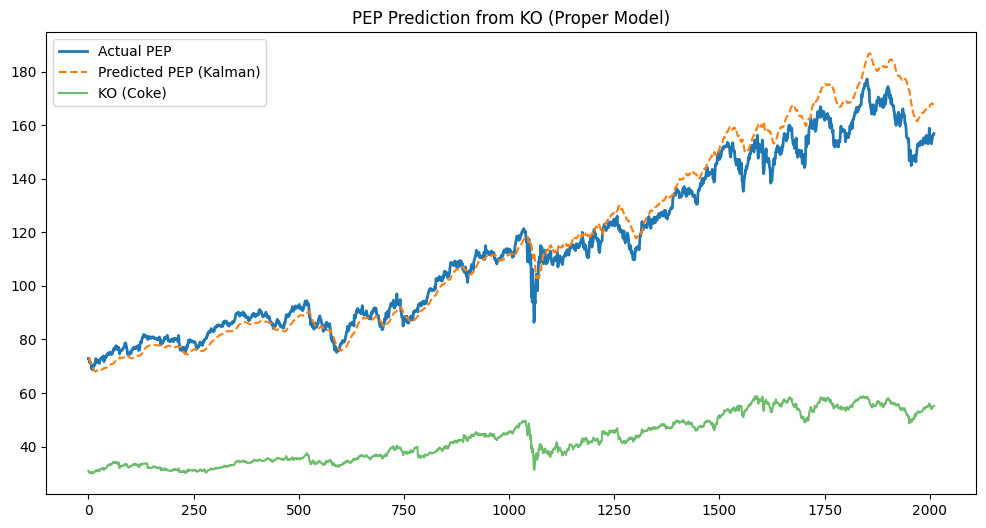

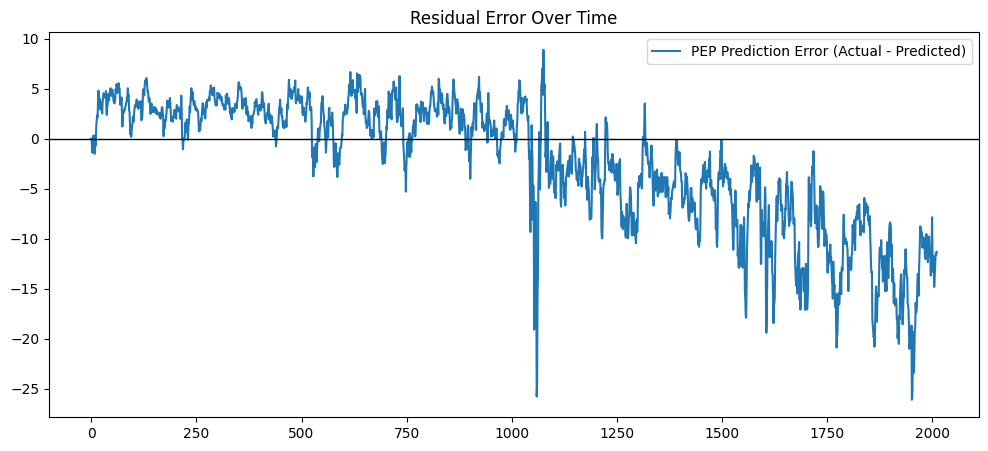

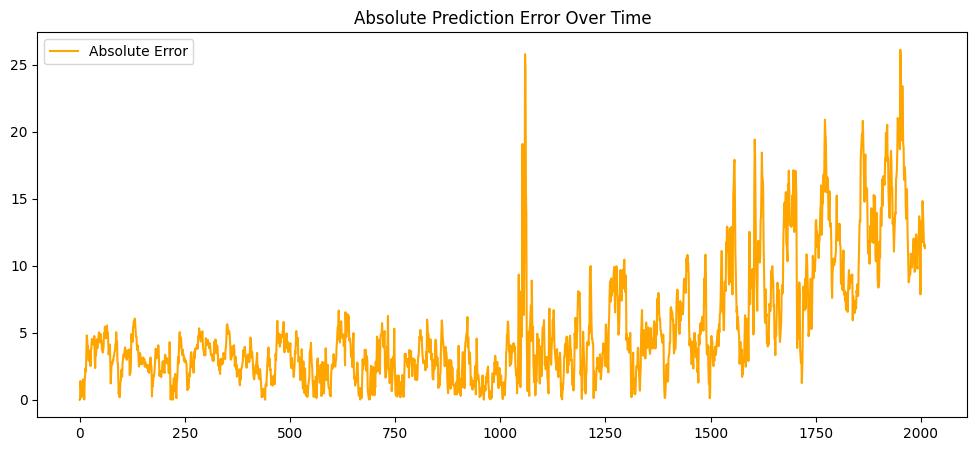

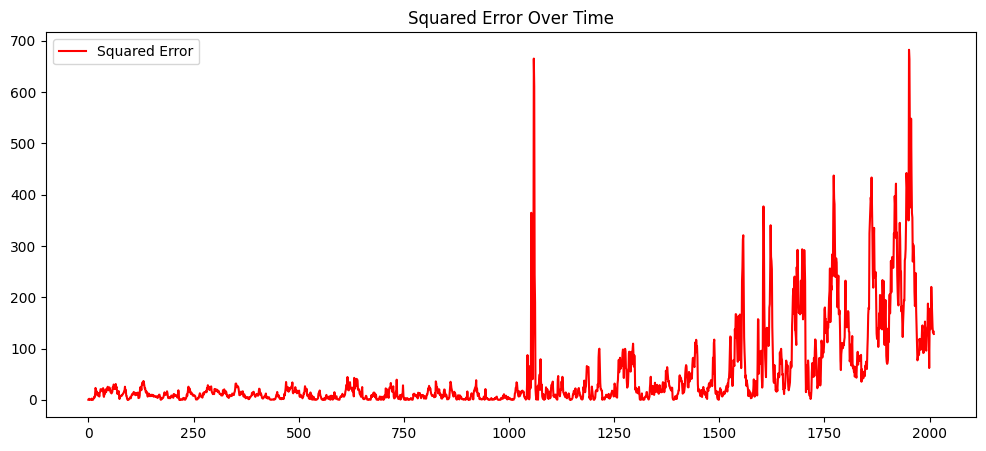

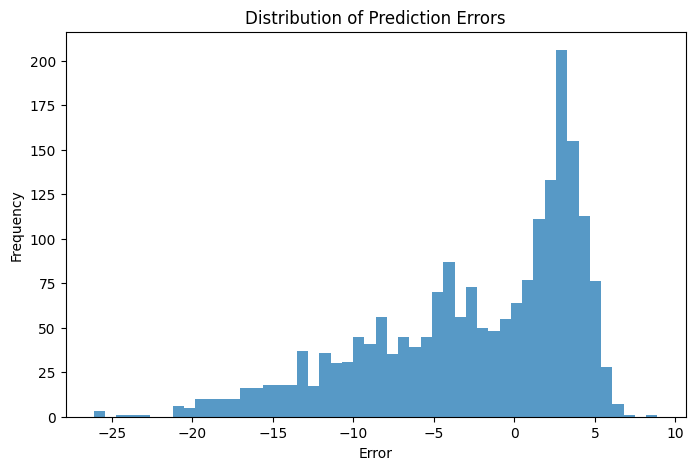

In [32]:




import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# ----------------------------
# LOAD DATA
# ----------------------------
tickers = ["KO", "PEP"]
data = yf.download(tickers, start="2016-01-01", end="2024-01-01")["Close"]
data = data.dropna()

# ----------------------------
# RETURNS
# ----------------------------
returns = data.pct_change().dropna()

y = returns["PEP"].values
x = returns["KO"].values

n = len(y)

# ----------------------------
# KALMAN FILTER (REAL MODEL)
# ----------------------------
def kalman_filter(x, y):
    n = len(y)

    x_hat = np.zeros((2, n))
    P = np.eye(2)

    A = np.eye(2)

    Q = 1e-5 * np.eye(2)   # keep it SMALL and stable
    R = 1e-3

    y_preds = np.zeros(n)

    for t in range(1, n):

        H = np.array([[1, x[t-1]]])

        x_pred = A @ x_hat[:, t-1]
        P_pred = A @ P @ A.T + Q

        y_pred = (H @ x_pred).item()
        y_preds[t] = y_pred

        error = y[t] - y_pred

        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)

        x_hat[:, t] = x_pred + K.flatten() * error
        P = (np.eye(2) - K @ H) @ P_pred

    return y_preds

# ----------------------------
# RUN MODEL
# ----------------------------
pred_returns = kalman_filter(x, y)

# ----------------------------
# REBUILD PRICE FROM RETURNS
# ----------------------------
pep_prices = data["PEP"].iloc[1:].values  # align with returns
pred_prices = np.zeros_like(pep_prices)

pred_prices[0] = pep_prices[0]

for t in range(1, len(pred_prices)):
    pred_prices[t] = pred_prices[t-1] * (1 + pred_returns[t])

# ----------------------------
# ALIGN KO FOR PLOT
# ----------------------------
ko_prices = data["KO"].iloc[1:].values

# ----------------------------
# FINAL PLOT (WHAT YOU ASKED)
# ----------------------------
plt.figure(figsize=(12,6))

plt.plot(pep_prices, label="Actual PEP", linewidth=2)
plt.plot(pred_prices, label="Predicted PEP (Kalman)", linestyle="--")
plt.plot(ko_prices, label="KO (Coke)", alpha=0.7)

plt.title("PEP Prediction from KO (Proper Model)")
plt.legend()
plt.show()

# ----------------------------
# ERROR COMPUTATION
# ----------------------------
error = pep_prices - pred_prices
abs_error = np.abs(error)
squared_error = error**2

# ----------------------------
# 1. RAW ERROR (Residual Plot)
# ----------------------------
plt.figure(figsize=(12,5))
plt.plot(error, label="PEP Prediction Error (Actual - Predicted)")
plt.axhline(0, color='black', linewidth=1)
plt.title("Residual Error Over Time")
plt.legend()
plt.show()

# ----------------------------
# 2. ABSOLUTE ERROR
# ----------------------------
plt.figure(figsize=(12,5))
plt.plot(abs_error, label="Absolute Error", color="orange")
plt.title("Absolute Prediction Error Over Time")
plt.legend()
plt.show()

# ----------------------------
# 3. SQUARED ERROR (Penalty View)
# ----------------------------
plt.figure(figsize=(12,5))
plt.plot(squared_error, label="Squared Error", color="red")
plt.title("Squared Error Over Time")
plt.legend()
plt.show()

# ----------------------------
# 4. ERROR DISTRIBUTION (Histogram)
# ----------------------------
plt.figure(figsize=(8,5))
plt.hist(error, bins=50, alpha=0.75)
plt.title("Distribution of Prediction Errors")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()


[*********************100%***********************]  2 of 2 completed


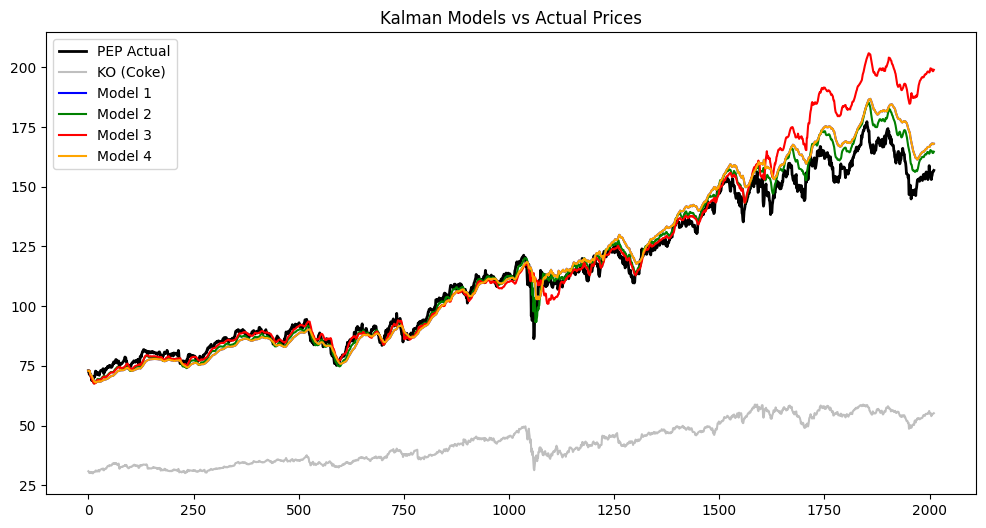

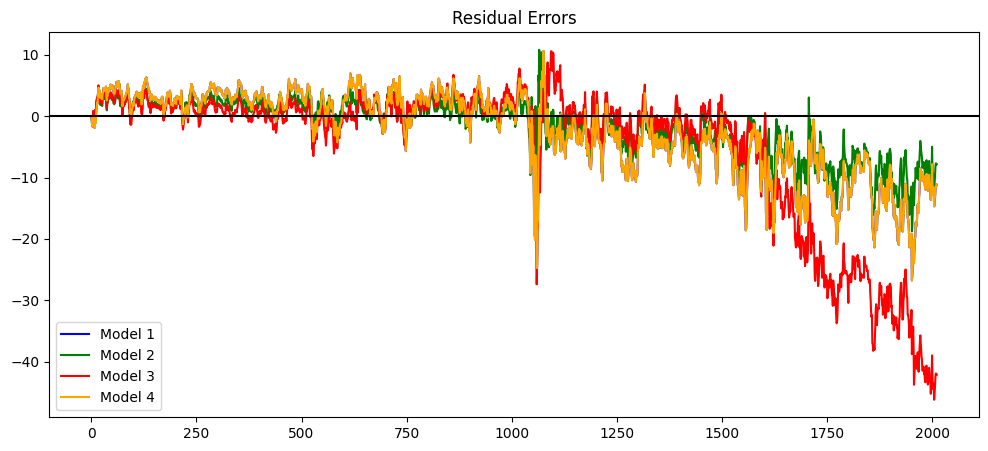

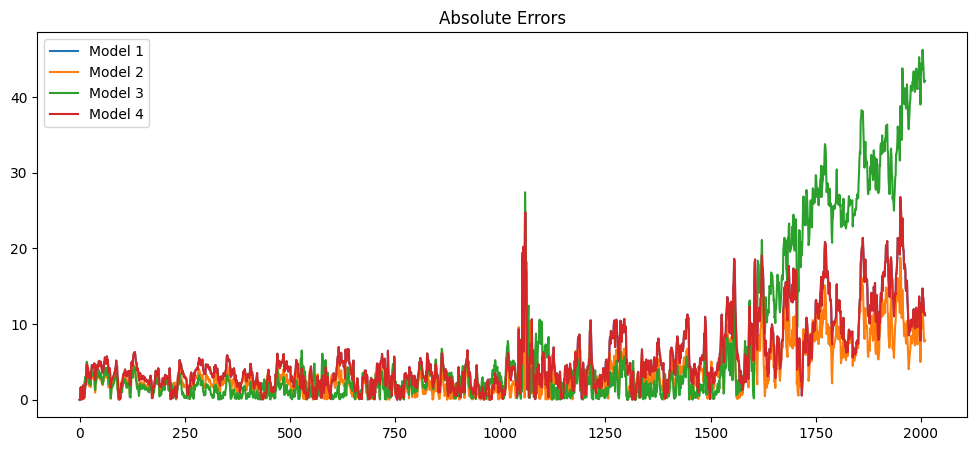

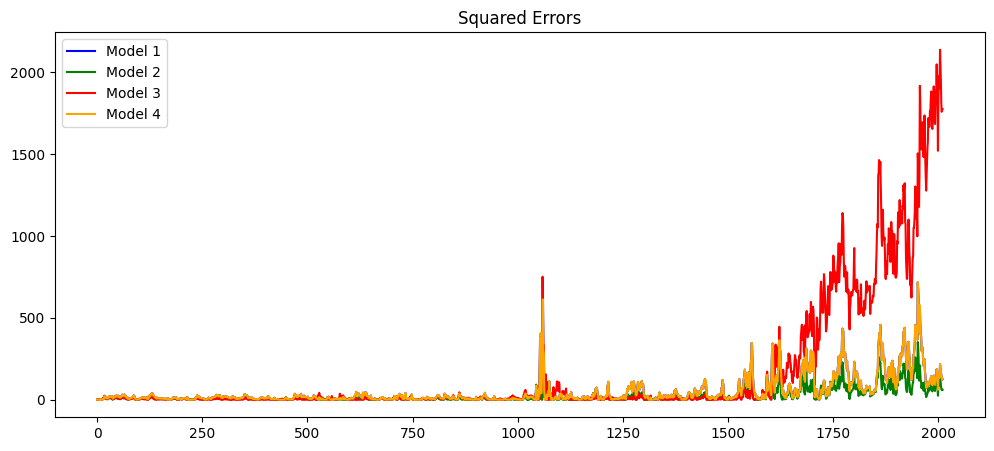

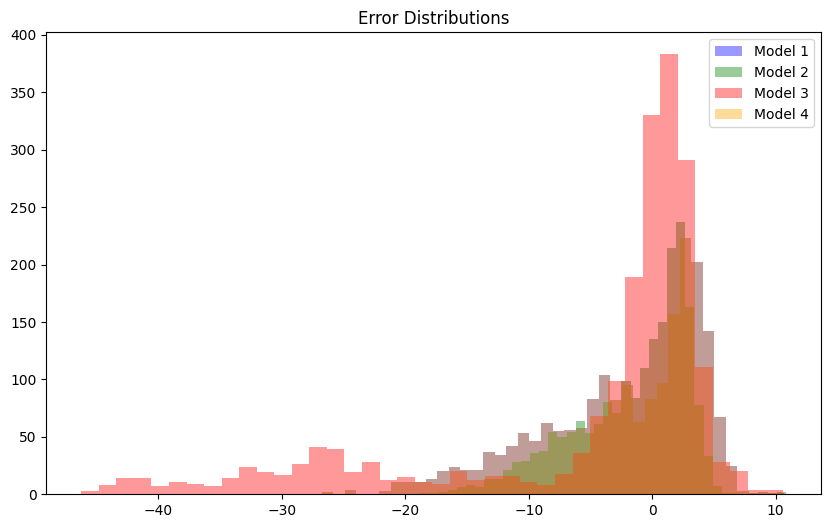

In [44]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# =========================================================
# LOAD DATA
# =========================================================
tickers = ["KO", "PEP"]
data = yf.download(tickers, start="2016-01-01", end="2024-01-01")["Close"].dropna()

returns = data.pct_change().dropna()

y = returns["PEP"].values
x = returns["KO"].values
n = len(y)

pep_prices = data["PEP"].values[1:]
ko_prices  = data["KO"].values[1:]


# =========================================================
# MODEL 1 — SIMPLE KALMAN (STABLE BASELINE)
# =========================================================
def model1(x, y):
    n = len(y)
    x_hat = np.zeros((2, n))
    P = np.eye(2)

    A = np.eye(2)
    Q = 1e-5 * np.eye(2)
    R = 1e-3

    y_pred = np.zeros(n)

    for t in range(1, n):

        H = np.array([[1, x[t-1]]])

        x_pred = A @ x_hat[:, t-1]
        P_pred = A @ P @ A.T + Q

        pred = (H @ x_pred).item()
        y_pred[t] = pred

        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)

        err = y[t] - pred
        x_hat[:, t] = x_pred + K.flatten() * err
        P = (np.eye(2) - K @ H) @ P_pred

    y_pred[0] = y_pred[1]
    return y_pred


# =========================================================
# MODEL 2 — KO + MOMENTUM
# =========================================================
def model2(x, y):
    x_hat = np.zeros((3, n))
    P = np.eye(3)

    A = np.eye(3)
    Q = 1e-3 * np.eye(3)
    R = 1e-2

    y_pred = np.zeros(n)

    for t in range(2, n):

        H = np.array([[1, x[t-1], y[t-1]]])

        x_pred = A @ x_hat[:, t-1]
        P_pred = A @ P @ A.T + Q

        y_pred[t] = (H @ x_pred).item()

        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)

        err = y[t] - y_pred[t]
        x_hat[:, t] = x_pred + K.flatten() * err
        P = (np.eye(3) - K @ H) @ P_pred

    return y_pred


# =========================================================
# MODEL 3 — ADAPTIVE + SHOCK RESET
# =========================================================
def model3(x, y):
    x_hat = np.zeros((3, n))
    P = np.eye(3)

    A = np.eye(3)
    R = 1e-2
    lam = 0.98

    y_pred = np.zeros(n)

    for t in range(2, n):

        H = np.array([[1, x[t-1], y[t-1]]])

        vol = np.var(y[max(0, t-20):t])
        Q = (1e-4 + 5 * vol) * np.eye(3)

        x_pred = A @ x_hat[:, t-1]
        P_pred = (A @ P @ A.T + Q) / lam

        y_pred[t] = (H @ x_pred).item()

        err = y[t] - y_pred[t]

        if abs(err) > 3 * np.std(y):
            x_hat[:, t] = 0
            P = np.eye(3) * 10
            continue

        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)

        x_hat[:, t] = x_pred + K.flatten() * err
        P = (np.eye(3) - K @ H) @ P_pred

    return y_pred


# =========================================================
# MODEL 4 — MINIMAL STABLE
# =========================================================
def model4(x, y):
    x_hat = np.zeros((2, n))
    P = np.eye(2)

    A = np.eye(2)
    Q = 1e-5 * np.eye(2)
    R = 1e-3

    y_pred = np.zeros(n)

    for t in range(1, n):

        H = np.array([[1, x[t-1]]])

        x_pred = A @ x_hat[:, t-1]
        P_pred = A @ P @ A.T + Q

        pred = (H @ x_pred).item()
        y_pred[t] = pred

        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)

        err = y[t] - pred
        x_hat[:, t] = x_pred + K.flatten() * err
        P = (np.eye(2) - K @ H) @ P_pred

    y_pred[0] = y_pred[1]
    return y_pred


# =========================================================
# RUN MODELS
# =========================================================
p1 = model1(x, y)
p2 = model2(x, y)
p3 = model3(x, y)
p4 = model4(x, y)


# =========================================================
# PRICE RECONSTRUCTION (FIXED ALIGNMENT)
# =========================================================
def rebuild(pred_returns, base):
    out = np.zeros_like(base)
    out[0] = base[0]
    for t in range(1, len(out)):
        out[t] = out[t-1] * (1 + pred_returns[t-1])
    return out

p1p = rebuild(p1, pep_prices)
p2p = rebuild(p2, pep_prices)
p3p = rebuild(p3, pep_prices)
p4p = rebuild(p4, pep_prices)


colors = {
    "m1": "blue",
    "m2": "green",
    "m3": "red",
    "m4": "orange"
}

# =========================================================
# 1. PRICE PLOT (NOW FIXED + KO INCLUDED)
# =========================================================
plt.figure(figsize=(12,6))

plt.plot(pep_prices, label="PEP Actual", linewidth=2, color="black")
plt.plot(ko_prices, label="KO (Coke)", alpha=0.5, color="gray")

plt.plot(p1p, label="Model 1", color=colors["m1"])
plt.plot(p2p, label="Model 2", color=colors["m2"])
plt.plot(p3p, label="Model 3", color=colors["m3"])
plt.plot(p4p, label="Model 4", color=colors["m4"])

plt.title("Kalman Models vs Actual Prices")
plt.legend()
plt.show()


# =========================================================
# ERROR METRICS
# =========================================================
def errors(pred):
    e = pep_prices - pred
    return e, np.abs(e), e**2

e1, ae1, se1 = errors(p1p)
e2, ae2, se2 = errors(p2p)
e3, ae3, se3 = errors(p3p)
e4, ae4, se4 = errors(p4p)


# =========================================================
# 2. RESIDUAL ERROR
# =========================================================
plt.figure(figsize=(12,5))

plt.plot(e1, label="Model 1", color=colors["m1"])
plt.plot(e2, label="Model 2", color=colors["m2"])
plt.plot(e3, label="Model 3", color=colors["m3"])
plt.plot(e4, label="Model 4", color=colors["m4"])

plt.axhline(0, color="black")
plt.title("Residual Errors")
plt.legend()
plt.show()


# =========================================================
# 3. ABS ERROR
# =========================================================
plt.figure(figsize=(12,5))
plt.plot(ae1, label="Model 1")
plt.plot(ae2, label="Model 2")
plt.plot(ae3, label="Model 3")
plt.plot(ae4, label="Model 4")
plt.title("Absolute Errors")
plt.legend()
plt.show()


# =========================================================
# 4. SQUARED ERROR
# =========================================================
plt.figure(figsize=(12,5))

plt.plot(se1, label="Model 1", color=colors["m1"])
plt.plot(se2, label="Model 2", color=colors["m2"])
plt.plot(se3, label="Model 3", color=colors["m3"])
plt.plot(se4, label="Model 4", color=colors["m4"])

plt.title("Squared Errors")
plt.legend()
plt.show()


# =========================================================
# 5. ERROR DISTRIBUTION
# =========================================================
plt.figure(figsize=(10,6))

plt.hist(e1, bins=40, alpha=0.4, label="Model 1", color=colors["m1"])
plt.hist(e2, bins=40, alpha=0.4, label="Model 2", color=colors["m2"])
plt.hist(e3, bins=40, alpha=0.4, label="Model 3", color=colors["m3"])
plt.hist(e4, bins=40, alpha=0.4, label="Model 4", color=colors["m4"])

plt.title("Error Distributions")
plt.legend()
plt.show()

[*********************100%***********************]  2 of 2 completed


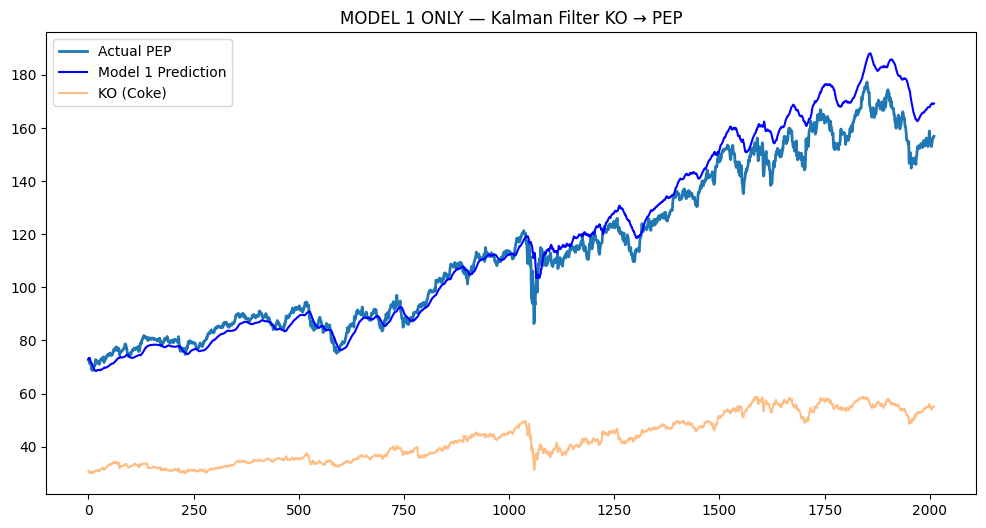

Pred return mean: 0.0004229316271915305
Pred return std: 0.0027843563014419304
First 10 predictions: [ 0.00688441  0.          0.00030155 -0.01079353 -0.00744642 -0.004661
 -0.00230221 -0.00489783 -0.00533187 -0.00721257]


In [45]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# =========================================================
# LOAD DATA
# =========================================================
data = yf.download(["KO", "PEP"], start="2016-01-01", end="2024-01-01")["Close"].dropna()

returns = data.pct_change().dropna()

x = returns["KO"].values
y = returns["PEP"].values
n = len(y)

pep_prices = data["PEP"].values[1:]
ko_prices = data["KO"].values[1:]


# =========================================================
# MODEL 1 — 2D KALMAN FILTER (KO → PEP)
# =========================================================
def model1(x, y):
    n = len(y)

    x_hat = np.zeros((2, n))
    P = np.eye(2)

    A = np.eye(2)
    Q = 1e-5 * np.eye(2)
    R = 1e-3

    y_pred = np.zeros(n)

    for t in range(1, n):

        # state: [alpha, beta]
        H = np.array([[1, x[t-1]]])

        # prediction step
        x_pred = A @ x_hat[:, t-1]
        P_pred = A @ P @ A.T + Q

        pred = (H @ x_pred).item()
        y_pred[t] = pred

        # update step
        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T @ np.linalg.inv(S)

        err = y[t] - pred
        x_hat[:, t] = x_pred + K.flatten() * err
        P = (np.eye(2) - K @ H) @ P_pred

    # 🔥 FIX: proper initialization so it is visible
    y_pred[0] = y[0]

    return y_pred


# =========================================================
# RUN MODEL
# =========================================================
pred_returns = model1(x, y)


# =========================================================
# PRICE RECONSTRUCTION (SAFE)
# =========================================================
pred_prices = np.zeros_like(pep_prices)
pred_prices[0] = pep_prices[0]

for t in range(1, len(pred_prices)):
    pred_prices[t] = pred_prices[t-1] * (1 + pred_returns[t-1])


# =========================================================
# PLOT CHECK
# =========================================================
plt.figure(figsize=(12,6))

plt.plot(pep_prices, label="Actual PEP", linewidth=2)
plt.plot(pred_prices, label="Model 1 Prediction", color="blue")
plt.plot(ko_prices, label="KO (Coke)", alpha=0.5)

plt.title("MODEL 1 ONLY — Kalman Filter KO → PEP")
plt.legend()
plt.show()


# =========================================================
# DEBUG: VERIFY IT IS NOT ZERO
# =========================================================
print("Pred return mean:", np.mean(pred_returns))
print("Pred return std:", np.std(pred_returns))
print("First 10 predictions:", pred_returns[:10])